# Loan Approval Prediction: Model Training & Evaluation

This notebook documents the full machine-learning workflow behind the Django application:
data checks, exploratory analysis, preprocessing, model comparison, tuning, evaluation and export.

**Design principles**

- The dataset is split into train/test **before** anything is fitted. The test set is used once, for final reporting.
- All preprocessing (scaling, one-hot encoding) lives inside a scikit-learn `Pipeline`, so it is fitted on training data only.
- Resampling (SMOTE) is only ever applied inside training folds, never to validation or test data.
- Models are **selected on cross-validated macro-F1**, never on the test set.

**Research questions addressed:** RQ1/RQ2 (model performance and differences), RQ3 (does handling class imbalance help, without leakage?), RQ5 (which inputs matter most).

> Run from the project root so that `import ml` works. The same code is packaged in `ml/train.py`, which produces the deployed model.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report, accuracy_score, f1_score)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate

from ml.config import (ARTIFACT_DIR, PIPELINE_PATH, METRICS_PATH, FEATURES,
                       NUMERIC_FEATURES, CATEGORICAL_FEATURES, RANDOM_STATE,
                       CV_FOLDS, SELECTION_METRIC)
from ml.preprocess import load_data, validate_data, make_xy, split_data, build_preprocessor
from ml.models import get_candidates, make_pipeline
from ml.train import evaluate, SCORING

sns.set_theme(style="whitegrid")
FIG_DIR = ARTIFACT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
print("Numeric features    :", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features    : ['age', 'income', 'credit_score']
Categorical features: ['occupation', 'education_level', 'marital_status']


## 2. Load data and check quality

In [2]:
df = load_data()
report = validate_data(df)
print(json.dumps(report, indent=2))
df.head()

{
  "rows": 1000,
  "missing_values": 0,
  "duplicate_rows": 0,
  "class_counts": {
    "Approved": 639,
    "Denied": 361
  }
}


,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,50,Female,Accountant,Bachelor's,Married,83255,669,Denied
1,36,Male,Teacher,Associate's,Single,81331,721,Approved
2,29,Male,Architect,Master's,Married,103052,724,Denied
3,42,Male,Teacher,Master's,Married,107014,734,Approved
4,40,Male,Accountant,High School,Married,58193,694,Denied


In [3]:
print("Numeric summary:")
display(df[NUMERIC_FEATURES].describe().round(1))
print("\nCategory counts:")
for c in CATEGORICAL_FEATURES + ["gender"]:
    print(f"  {c}: {df[c].nunique()} levels")

Numeric summary:


,age,income,credit_score
count,1000.0,1000.0,1000.0
mean,40.9,85548.9,737.3
std,11.2,30407.6,66.1
min,22.0,20000.0,521.0
25%,31.0,64965.8,690.8
50%,42.0,84122.0,737.0
75%,50.0,106239.2,787.0
max,59.0,166744.0,850.0



Category counts:
  occupation: 20 levels
  education_level: 5 levels
  marital_status: 2 levels
  gender: 2 levels


The dataset has no missing values, no duplicate rows and no out-of-range values (credit scores are within 300-850, ages are adult).
The target is moderately imbalanced (roughly 64% Approved / 36% Denied), so we test whether that matters in section 6.

## 3. Exploratory data analysis

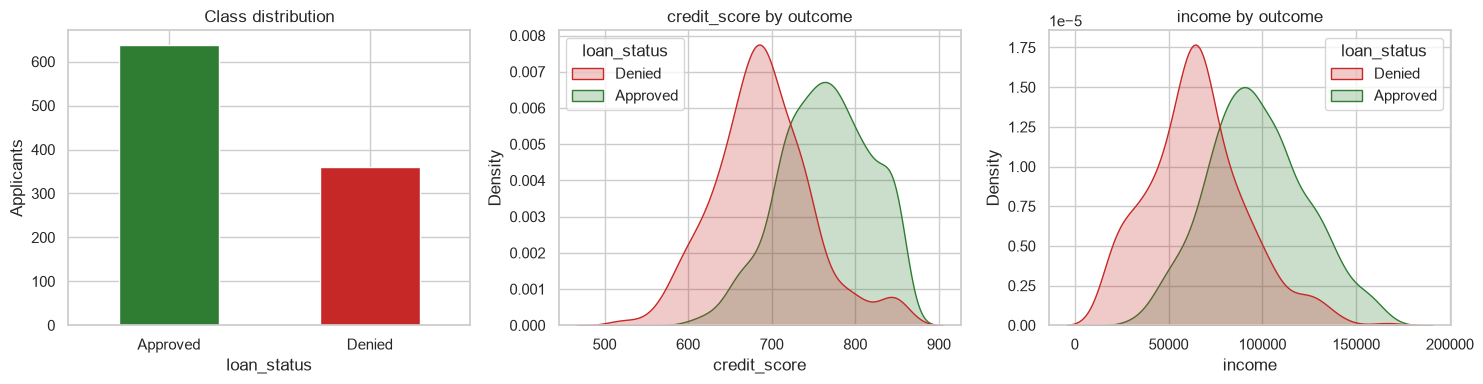

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["loan_status"].value_counts().plot(kind="bar", ax=axes[0], color=["#2e7d32", "#c62828"], rot=0)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("Applicants")
for i, col in enumerate(["credit_score", "income"]):
    sns.kdeplot(data=df, x=col, hue="loan_status", fill=True, common_norm=False,
                palette={"Approved": "#2e7d32", "Denied": "#c62828"}, ax=axes[i + 1])
    axes[i + 1].set_title(f"{col} by outcome")
plt.tight_layout(); plt.savefig(FIG_DIR / "eda_distributions.png", dpi=130); plt.show()

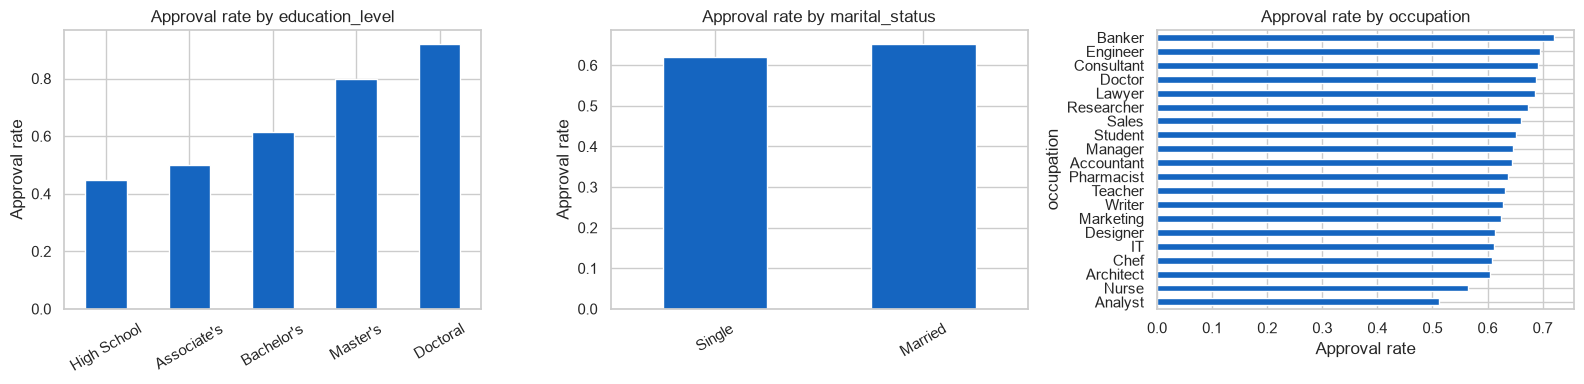

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["education_level", "marital_status", "occupation"]):
    rate = (df.assign(approved=(df.loan_status == "Approved"))
              .groupby(col)["approved"].mean().sort_values())
    rate.plot(kind="barh" if col == "occupation" else "bar", ax=ax, color="#1565c0")
    ax.set_title(f"Approval rate by {col}")
    ax.set_xlabel("") if col != "occupation" else ax.set_xlabel("Approval rate")
    if col != "occupation": ax.set_ylabel("Approval rate"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(FIG_DIR / "eda_categories.png", dpi=130); plt.show()

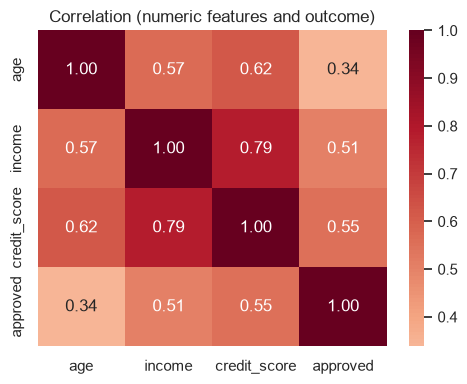

In [6]:
num = df[NUMERIC_FEATURES].copy()
num["approved"] = (df.loan_status == "Approved").astype(int)
plt.figure(figsize=(5, 4))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation (numeric features and outcome)")
plt.tight_layout(); plt.savefig(FIG_DIR / "eda_correlation.png", dpi=130); plt.show()

## 4. Preprocessing design

| Feature type | Columns | Treatment | Why |
|---|---|---|---|
| Numeric | age, income, credit_score | `StandardScaler` | Needed by Logistic Regression; harmless for tree models |
| Nominal categorical | occupation, education_level, marital_status | `OneHotEncoder(handle_unknown="ignore")` | These have no natural numeric order, so integer label-encoding would impose a false ordering |
| Not used | gender | Excluded from the model | Sensitive attribute; section 9 shows it does not improve performance |

Both steps sit inside a `ColumnTransformer` that is part of the model `Pipeline`, so it is re-fitted on the training portion of every CV fold.

In [7]:
X, y = make_xy(df)                 # y: 1 = Approved, 0 = Denied
pre = build_preprocessor().fit(X)
print("Transformed feature count:", len(pre.get_feature_names_out()))
print(list(pre.get_feature_names_out())[:8], "...")

Transformed feature count: 30
['age', 'income', 'credit_score', 'occupation_Accountant', 'occupation_Analyst', 'occupation_Architect', 'occupation_Banker', 'occupation_Chef'] ...


## 5. Train/test split and baseline

In [8]:
X_train, X_test, y_train, y_test = split_data(X, y)
cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (never used for tuning or selection)")
print("Approved share  train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline = {"accuracy": accuracy_score(y_test, dummy.predict(X_test)),
            "f1_macro": f1_score(y_test, dummy.predict(X_test), average="macro")}
print("\nMajority-class baseline on test set:", {k: round(v, 3) for k, v in baseline.items()})

Train: 800 rows | Test: 200 rows (never used for tuning or selection)
Approved share  train: 0.639 | test: 0.640

Majority-class baseline on test set: {'accuracy': 0.64, 'f1_macro': 0.39}


Any useful model must beat the baseline of always predicting *Approved*, which is right about 64% of the time but never identifies a denial.

## 6. Does class imbalance need handling? (RQ3)

We compare three strategies for each model, using stratified 5-fold CV on the **training set only**.
For SMOTE the resampler sits *inside* the pipeline, so synthetic rows are created only from training folds and validation folds stay untouched (no leakage).

In [9]:
fixed = {
    "Logistic Regression": dict(C=1.0),
    "Random Forest": dict(n_estimators=200, max_depth=5, min_samples_leaf=3),
    "XGBoost": dict(n_estimators=150, max_depth=3, learning_rate=0.1),
}
rows = []
for name, (est, _) in get_candidates().items():
    for strategy in ["none", "class_weight", "smote"]:
        model = est.set_params(**fixed[name])
        if strategy == "class_weight":
            if name == "XGBoost":
                model.set_params(scale_pos_weight=float((y_train == 0).sum() / (y_train == 1).sum()))
            else:
                model.set_params(class_weight="balanced")
        pipe = make_pipeline(model, use_smote=(strategy == "smote"))
        res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING)
        rows.append({"model": name, "strategy": strategy,
                     "cv_f1_macro": res["test_f1_macro"].mean(),
                     "f1_macro_std": res["test_f1_macro"].std(),
                     "cv_roc_auc": res["test_roc_auc"].mean(),
                     "cv_accuracy": res["test_accuracy"].mean()})
imb = pd.DataFrame(rows)
display(imb.round(3))

,model,strategy,cv_f1_macro,f1_macro_std,cv_roc_auc,cv_accuracy
0,Logistic Regression,none,0.739,0.053,0.838,0.764
1,Logistic Regression,class_weight,0.753,0.030,0.837,0.764
2,Logistic Regression,smote,0.743,0.049,0.832,0.755
3,Random Forest,none,0.759,0.028,0.850,0.792
4,Random Forest,class_weight,0.769,0.040,0.848,0.785
5,Random Forest,smote,0.753,0.049,0.847,0.769
6,XGBoost,none,0.757,0.033,0.833,0.784
7,XGBoost,class_weight,0.752,0.027,0.833,0.769
8,XGBoost,smote,0.747,0.027,0.835,0.759


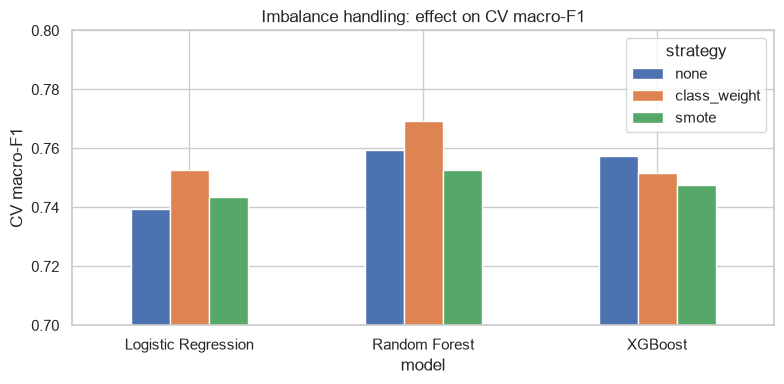

Largest gain from any strategy vs 'none': 0.013  |  typical fold-to-fold std: 0.037


In [10]:
piv = imb.pivot(index="model", columns="strategy", values="cv_f1_macro")[["none", "class_weight", "smote"]]
ax = piv.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylim(0.70, 0.80); ax.set_ylabel("CV macro-F1"); ax.set_title("Imbalance handling: effect on CV macro-F1")
plt.tight_layout(); plt.savefig(FIG_DIR / "imbalance_experiment.png", dpi=130); plt.show()
print("Largest gain from any strategy vs 'none': %.3f  |  typical fold-to-fold std: %.3f"
      % ((piv.sub(piv["none"], axis=0)).max().max(), imb.f1_macro_std.mean()))

## 7. Hyperparameter tuning and model comparison (RQ1, RQ2)

In [11]:
results, tuned = {}, {}
for name, (est, grid) in get_candidates().items():
    gs = GridSearchCV(make_pipeline(est), grid, scoring=SCORING, refit=SELECTION_METRIC, cv=cv, n_jobs=1)
    gs.fit(X_train, y_train)
    i = gs.best_index_
    results[name] = {
        "best_params": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()},
        "cv": {m: gs.cv_results_[f"mean_test_{m}"][i] for m in SCORING},
        "cv_std": {m: gs.cv_results_[f"std_test_{m}"][i] for m in SCORING},
        "test": evaluate(gs.best_estimator_, X_test, y_test),
    }
    tuned[name] = gs.best_estimator_
    print(f"{name:20s} best params: {results[name]['best_params']}")

Logistic Regression  best params: {'C': 0.1}
Random Forest        best params: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 200}
XGBoost              best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [12]:
table = pd.DataFrame({
    name: {
        "CV Accuracy": r["cv"]["accuracy"], "CV F1 (macro)": r["cv"]["f1_macro"],
        "CV F1 std": r["cv_std"]["f1_macro"], "CV ROC-AUC": r["cv"]["roc_auc"],
        "Test Accuracy": r["test"]["accuracy"], "Test Precision": r["test"]["precision"],
        "Test Recall": r["test"]["recall"], "Test F1 (macro)": r["test"]["f1_macro"],
        "Test ROC-AUC": r["test"]["roc_auc"],
    } for name, r in results.items()
}).T
table.loc["Majority-class baseline", ["Test Accuracy", "Test F1 (macro)"]] = [baseline["accuracy"], baseline["f1_macro"]]
display(table.round(3))

selected = max(results, key=lambda n: results[n]["cv"][SELECTION_METRIC])
print(f"\nSelected model (highest CV {SELECTION_METRIC}): {selected}")

,CV Accuracy,CV F1 (macro),CV F1 std,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1 (macro),Test ROC-AUC
Logistic Regression,0.776,0.752,0.052,0.847,0.780,0.809,0.859,0.755,0.823
Random Forest,0.796,0.766,0.031,0.848,0.785,0.824,0.844,0.765,0.836
XGBoost,0.800,0.771,0.049,0.847,0.800,0.828,0.867,0.779,0.846
Majority-class baseline,NaN,NaN,NaN,NaN,0.640,NaN,NaN,0.390,NaN



Selected model (highest CV f1_macro): XGBoost


*Precision and recall in the table use **Approved** as the positive class.* Selection uses cross-validation only; the test columns are reported for all models but were not used to choose between them.

## 8. Detailed evaluation on the held-out test set

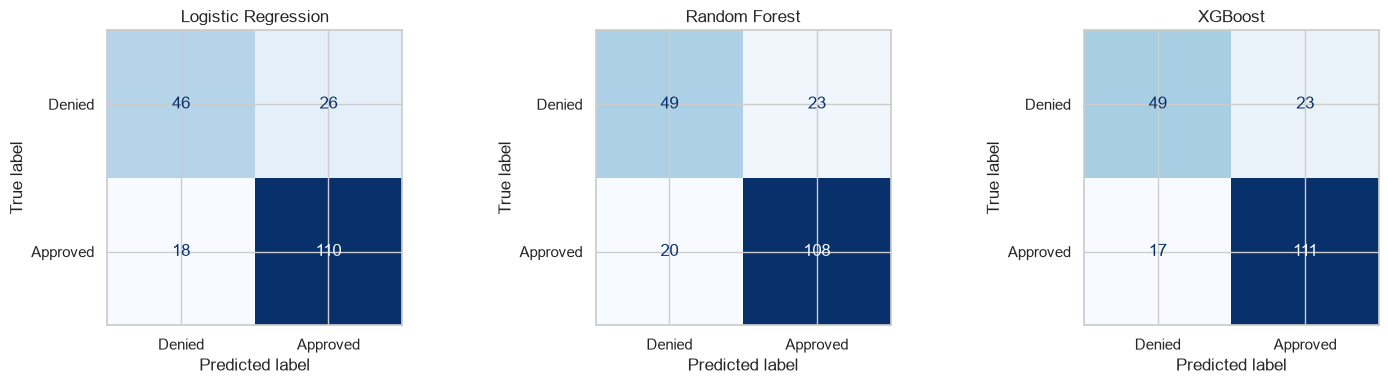

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, tuned.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, display_labels=["Denied", "Approved"],
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=130); plt.show()

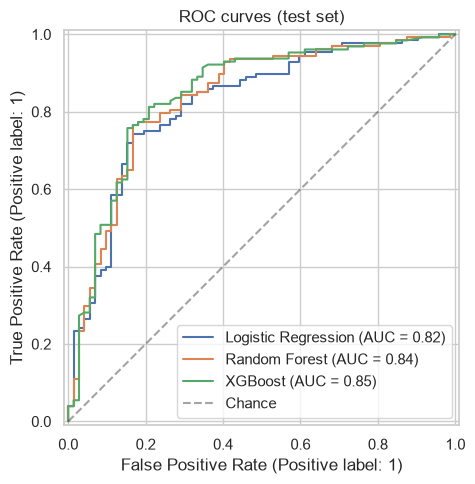

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in tuned.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=.4, label="Chance")
ax.set_title("ROC curves (test set)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIG_DIR / "roc_curves.png", dpi=130); plt.show()

In [15]:
print(f"Classification report: {selected}\n")
print(classification_report(y_test, tuned[selected].predict(X_test), target_names=["Denied", "Approved"]))

Classification report: XGBoost

              precision    recall  f1-score   support

      Denied       0.74      0.68      0.71        72
    Approved       0.83      0.87      0.85       128

    accuracy                           0.80       200
   macro avg       0.79      0.77      0.78       200
weighted avg       0.80      0.80      0.80       200



### Which inputs matter most? (RQ5)

Permutation importance measures how much the test score drops when one *original* input column is shuffled. It works for any model and keeps each categorical variable as one feature (rather than 20 one-hot columns).

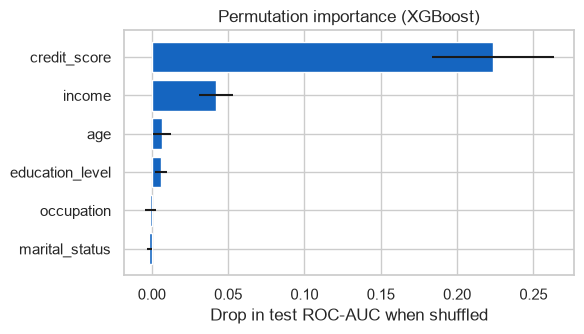

,importance
credit_score,0.2234
income,0.0421
age,0.0067
education_level,0.0059
occupation,-0.0010
marital_status,-0.0015


In [16]:
pi = permutation_importance(tuned[selected], X_test, y_test, scoring="roc_auc",
                            n_repeats=30, random_state=RANDOM_STATE)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
err = pd.Series(pi.importances_std, index=X_test.columns)[imp.index]
plt.figure(figsize=(6, 3.5))
plt.barh(imp.index, imp.values, xerr=err.values, color="#1565c0")
plt.xlabel("Drop in test ROC-AUC when shuffled"); plt.title(f"Permutation importance ({selected})")
plt.tight_layout(); plt.savefig(FIG_DIR / "permutation_importance.png", dpi=130); plt.show()
display(imp.sort_values(ascending=False).round(4).to_frame("importance"))

## 9. Fairness checks

**Is gender needed?** We compare cross-validated performance with and without `gender` as an input.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def cv_with_cats(name, cats):
    est, _ = get_candidates()[name]
    est.set_params(**results[name]["best_params"])
    pre = ColumnTransformer([("num", StandardScaler(), NUMERIC_FEATURES),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cats)])
    r = cross_validate(Pipeline([("pre", pre), ("clf", est)]),
                       df.loc[X_train.index, NUMERIC_FEATURES + cats], y_train, cv=cv, scoring=SCORING)
    return r["test_f1_macro"].mean(), r["test_roc_auc"].mean()

abl = []
for name in results:
    f_wo, a_wo = cv_with_cats(name, CATEGORICAL_FEATURES)
    f_w, a_w = cv_with_cats(name, CATEGORICAL_FEATURES + ["gender"])
    abl.append({"model": name, "F1 without gender": f_wo, "F1 with gender": f_w,
                "AUC without gender": a_wo, "AUC with gender": a_w, "AUC change": a_w - a_wo})
display(pd.DataFrame(abl).round(3))

,model,F1 without gender,F1 with gender,AUC without gender,AUC with gender,AUC change
0,Logistic Regression,0.752,0.752,0.847,0.847,0.000
1,Random Forest,0.766,0.760,0.848,0.849,0.001
2,XGBoost,0.771,0.777,0.847,0.844,-0.003


**Does the deployed model behave similarly across groups?** Subgroup results on the 200 test rows (gender is used only to *report*, not as a model input). Groups are small, so treat differences as indicative, not conclusive.

In [18]:
sub = df.loc[X_test.index].copy()
sub["pred"] = tuned[selected].predict(X_test)
sub["true"] = y_test
sub["correct"] = sub.pred == sub.true
out = []
for col in ["gender", "marital_status", "education_level"]:
    for g, d in sub.groupby(col):
        out.append({"attribute": col, "group": g, "n": len(d),
                    "actual approval rate": d.true.mean(), "predicted approval rate": d.pred.mean(),
                    "accuracy": d.correct.mean()})
display(pd.DataFrame(out).round(3))

,attribute,group,n,actual approval rate,predicted approval rate,accuracy
0,gender,Female,101,0.644,0.723,0.842
1,gender,Male,99,0.636,0.616,0.758
2,marital_status,Married,124,0.645,0.694,0.806
3,marital_status,Single,76,0.632,0.632,0.789
4,education_level,Associate's,27,0.407,0.444,0.815
5,education_level,Bachelor's,84,0.571,0.607,0.750
6,education_level,Doctoral,23,0.913,1.000,0.913
7,education_level,High School,23,0.609,0.435,0.826
8,education_level,Master's,43,0.791,0.884,0.814


## 10. Verify the exported model

The deployed model (`ml/artifacts/loan_pipeline.joblib`) is produced by `python -m ml.train`. It is selected the same way as above and then refitted on all rows. Here we confirm that this notebook reproduces the same numbers and that the saved pipeline works end to end.

In [19]:
saved = json.loads(METRICS_PATH.read_text())
assert saved["selected_model"] == selected, (saved["selected_model"], selected)
for name in results:
    a, b = results[name]["test"]["f1_macro"], saved["candidates"][name]["test"]["f1_macro"]
    assert abs(a - b) < 1e-9, (name, a, b)
print("Notebook results match the exported metrics.json for all models. Selected:", saved["selected_model"])

deployed = joblib.load(PIPELINE_PATH)
sample = pd.DataFrame([{"age": 38, "income": 120000, "credit_score": 790,
                        "occupation": "Engineer", "education_level": "Master's",
                        "marital_status": "Married"}])[FEATURES]
p = deployed.predict_proba(sample)[0, 1]
print(f"Sample applicant -> P(approved) = {p:.1%}")

Notebook results match the exported metrics.json for all models. Selected: XGBoost
Sample applicant -> P(approved) = 94.4%


## 11. Summary of findings

**Data.** 1,000 records, 6 model inputs (age, income, credit score, occupation, education, marital status), no missing values or duplicates. Class split is 64% Approved / 36% Denied. `gender` is available but not used as a model input.

**RQ1: How accurate are the models?** On the untouched 200-row test set the selected model (XGBoost) reaches **80.0% accuracy, macro-F1 0.78 and ROC-AUC 0.85**, versus 64.0% accuracy and macro-F1 0.39 for the majority-class baseline. For the Denied class, precision is 0.74 and recall 0.68; for Approved, precision is 0.83 and recall 0.87. With only 200 test rows, the 95% margin on accuracy is roughly +/-5.5 percentage points.

**RQ2: How do the models differ?** XGBoost (CV macro-F1 0.771), Random Forest (0.766) and Logistic Regression (0.752) are very close. The gaps between them (at most 0.02) are smaller than the fold-to-fold standard deviation (0.03 to 0.05), so **the data does not support claiming one algorithm is clearly better**. XGBoost was selected because it had the highest CV score, a rule fixed before looking at the test set. The simple linear model comes within about 2 points, which suggests the signal in this dataset is mostly simple.

**RQ3: Does handling class imbalance help?** No meaningful gain. Across three models and three strategies, the best improvement over doing nothing was 0.013 macro-F1, well inside the noise, and SMOTE was never clearly better than the alternatives. The imbalance is mild (about 64/36), so the final model uses no resampling. This also keeps predicted probabilities on their natural scale, which matters because the app displays them to users.

**RQ5: Which inputs matter?** Almost entirely **credit score** (dropping test ROC-AUC by about 0.22 when shuffled), then **income** (about 0.04). Age and education add very little; occupation and marital status contribute nothing measurable. Note that education *looks* important on its own (approval rises from 45% for High School to 92% for Doctoral), but higher education also goes with much higher credit scores (average 707 to 799) and incomes (about $60k to $129k), so once those two are known education adds almost nothing. Importance here means predictive value given the other inputs, not causation.

**Fairness.** Adding `gender` changed cross-validated AUC by between -0.003 and +0.001, so it brings no benefit and is left out. Even so, on the small test set the model predicted approval for 72% of women versus 62% of men, while actual approval rates were 64% in both groups. With roughly 100 people per group this gap is within sampling noise, but it should be monitored and cannot be ruled out as a real effect with this sample size.

**Limitations.** Small dataset (1,000 rows) with likely synthetic or simplified features; no debt, loan amount or repayment history; results may not generalise to real lenders. The output is a model estimate for demonstration, not a lending decision.